=== Dataset 1: Gaming Academic Performance ===
MAE: 4.8582
MSE: 39.3620
RMSE: 6.2739
R2: 0.9215


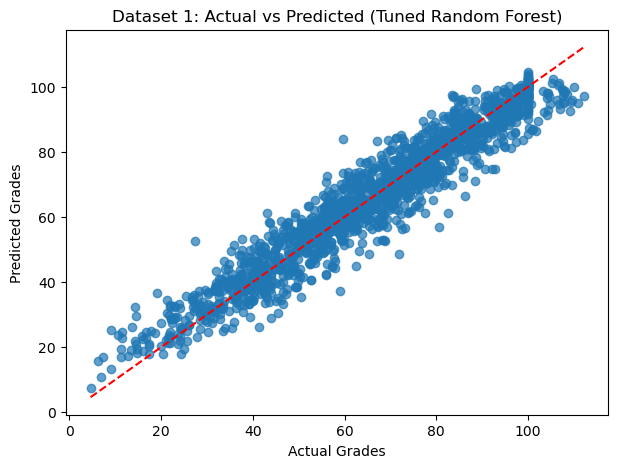

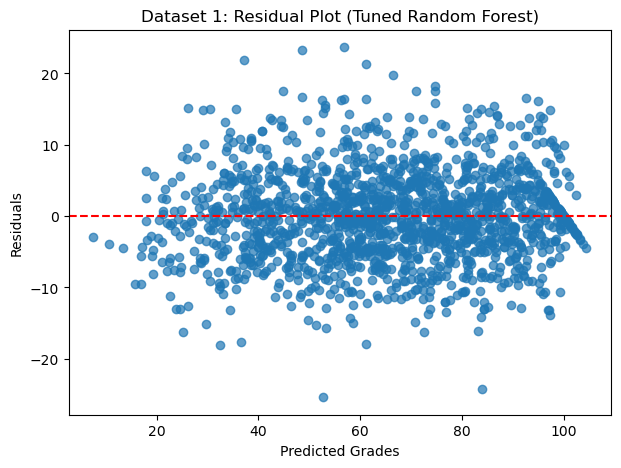


=== Dataset 2: AI Student Life ===
MAE: 0.1181
MSE: 0.0191
RMSE: 0.1382
R2: -0.0196


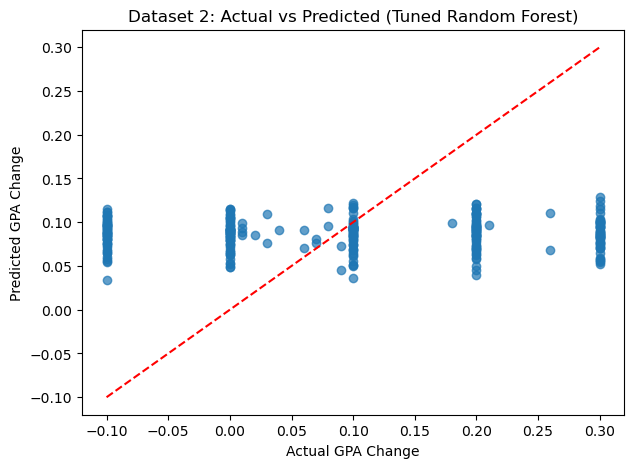

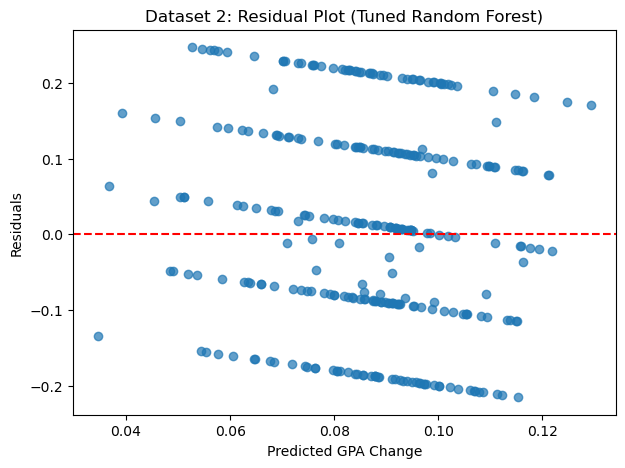

In [1]:
#Section 4: Results, Evaluation, and Literature Comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# DATASET 1: Gaming Academic Performance
# Best model = Tuned Random Forest
df1 = pd.read_csv("Gaming_Academic_Performance.csv")
df1 = df1.drop(columns=["student_id"])

X1 = df1.drop(columns=["grades"])
y1 = df1["grades"]

numeric_features_1 = X1.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_1 = X1.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer_1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer_1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_1 = ColumnTransformer(transformers=[
    ("num", numeric_transformer_1, numeric_features_1),
    ("cat", categorical_transformer_1, categorical_features_1)
])

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

best_model_1 = Pipeline(steps=[
    ("preprocessor", preprocessor_1),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        random_state=42
    ))
])

best_model_1.fit(X1_train, y1_train)
y1_pred = best_model_1.predict(X1_test)

mae1 = mean_absolute_error(y1_test, y1_pred)
mse1 = mean_squared_error(y1_test, y1_pred)
rmse1 = np.sqrt(mse1)
r21 = r2_score(y1_test, y1_pred)

print("=== Dataset 1: Gaming Academic Performance ===")
print(f"MAE: {mae1:.4f}")
print(f"MSE: {mse1:.4f}")
print(f"RMSE: {rmse1:.4f}")
print(f"R2: {r21:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(7,5))
plt.scatter(y1_test, y1_pred, alpha=0.7)
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'r--')
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Dataset 1: Actual vs Predicted (Tuned Random Forest)")
plt.show()

# Residual plot
residuals1 = y1_test - y1_pred
plt.figure(figsize=(7,5))
plt.scatter(y1_pred, residuals1, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Grades")
plt.ylabel("Residuals")
plt.title("Dataset 1: Residual Plot (Tuned Random Forest)")
plt.show()

# DATASET 2: AI Student Life
# Best model = Tuned Random Forest

df2 = pd.read_csv("AI_Impact_Student_Life_2026.csv")
df2["GPA_Change"] = df2["GPA_Post_AI"] - df2["GPA_Baseline"]

if "Student_ID" in df2.columns:
    df2 = df2.drop(columns=["Student_ID"])

X2 = df2.drop(columns=["GPA_Change", "GPA_Post_AI", "GPA_Baseline"])
y2 = df2["GPA_Change"]

numeric_features_2 = X2.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_2 = X2.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_2 = ColumnTransformer(transformers=[
    ("num", numeric_transformer_2, numeric_features_2),
    ("cat", categorical_transformer_2, categorical_features_2)
])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

best_model_2 = Pipeline(steps=[
    ("preprocessor", preprocessor_2),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_split=2,
        random_state=42
    ))
])

best_model_2.fit(X2_train, y2_train)
y2_pred = best_model_2.predict(X2_test)

mae2 = mean_absolute_error(y2_test, y2_pred)
mse2 = mean_squared_error(y2_test, y2_pred)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y2_test, y2_pred)

print("\n=== Dataset 2: AI Student Life ===")
print(f"MAE: {mae2:.4f}")
print(f"MSE: {mse2:.4f}")
print(f"RMSE: {rmse2:.4f}")
print(f"R2: {r22:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(7,5))
plt.scatter(y2_test, y2_pred, alpha=0.7)
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--')
plt.xlabel("Actual GPA Change")
plt.ylabel("Predicted GPA Change")
plt.title("Dataset 2: Actual vs Predicted (Tuned Random Forest)")
plt.show()

# Residual plot
residuals2 = y2_test - y2_pred
plt.figure(figsize=(7,5))
plt.scatter(y2_pred, residuals2, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted GPA Change")
plt.ylabel("Residuals")
plt.title("Dataset 2: Residual Plot (Tuned Random Forest)")
plt.show()

Section 4: Resukts, Evaluation, and Literature comparison
This section evaluates the final tuned models for both datasets, using regression metrics and visual analysis. Both predictions task are regression, the models use MAE, MSE, RMSE, and R^2, along with actual and predicted plots. Then the residual plots.

Dataset 1:
For the Gaming Academic Performance dataset, the final model was the Tuned Random Forest Regressor. The model achieved strong predictive performance. The evaluation results were MAE = 4.8582, MSE = 39.3620, RMSE = 6.2739, and R² = 0.9215.

These results show that the model predicts students grades with low error with a 92.15% of the variance in academic performance. This is a good result for the regression task and suggests that the gaming related and lifestyle-related features in the dataset provide meaningful predictive information. 

The actual vs. predicted plot shows that most of the points are close to the diagonal reference line. This shows that the model's predicted grades are pretty close to the actual grade values. This pattern is shown on the visual to match the r^2 and confirms the model fits the dataset well.

The residual plot also supports this conclusion. Most residuals are centered around zero, which suggests that the model is not consistently overpredicting. 